# 05 · Hypothesis Testing and Confidence Intervals

Up to now we only described data. From here on we start **deciding**: is this difference real, or could it just be luck?

**What you will learn here**

1. The idea of hypothesis testing, with a coin
2. Null and alternative hypotheses
3. The p-value: what it is and what it is not
4. Significance level (α) and rejection regions
5. One-tailed vs two-tailed tests
6. Type I and type II errors, and power
7. Confidence intervals (with z and with t)
8. What a "95% confidence interval" really means

**Datasets:** simulated coin tosses (so we know the truth), the restaurant **tips** data and the **Galton heights** data from the previous notebooks.

> **Colour guide:** $\color{red}{\text{red}}$ marks a rejected null hypothesis, a warning or a wrong reading. $\color{green}{\text{green}}$ marks a null hypothesis we fail to reject, a passed check or a correct reading.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

tips = pd.read_csv("../data/tips.csv")
tips["tip_percent"] = tips["tip"] / tips["total_bill"] * 100

galton = pd.read_csv("../data/galton_heights.csv")
men = galton.loc[galton["gender"] == "male", "childHeight"] * 2.54

---
## 1. The idea, with a coin

A friend gives you a coin and says it is fair. You toss it 100 times and get **60 heads**. Is the coin unfair?

A fair coin gives *about* 50 heads, but not exactly 50 every time. 52 would not surprise anyone. 90 would. Where is the line? Hypothesis testing is a fixed recipe to answer this.

It works like a court case:

| Court | Hypothesis test |
|---|---|
| The person is innocent until proven guilty | We assume "nothing special is going on" (H₀) until the data says otherwise |
| Evidence | The data |
| "Beyond reasonable doubt" | The significance level α |
| Verdict: guilty / not guilty | $\color{red}{\text{Reject } H_0}$ / $\color{green}{\text{fail to reject } H_0}$ |

Note: a court never declares someone "innocent", only "not guilty". In the same way, we never "prove" H₀, we only $\color{green}{\textbf{fail to reject}}$ it.

## 2. Null and alternative hypotheses

> **Theory**
>
> - **Null hypothesis (H₀):** the boring default, "no effect, no difference". Here: the coin is fair, P(head) = 0.5.
> - **Alternative hypothesis (H₁):** the opposite of H₀, what we suspect. Here: the coin is not fair, P(head) ≠ 0.5.

### The six steps of every test

1. State H₀
2. State H₁
3. Choose the significance level α (often 0.05)
4. Decide which test to use and the decision rule
5. Calculate the test statistic and/or the p-value
6. Make the decision and explain it in plain words

---
## 3. The p-value

> **Theory**
>
> The **p-value** is the probability of getting a result **at least as extreme** as the one we observed, **if H₀ were true**.

A small p-value means: "if the coin were fair, a result like ours would be very rare". So either we saw something very rare, or H₀ is wrong.

**Let's find it by simulation.** We ask the computer to toss a truly fair coin 100 times, and repeat this experiment 100,000 times. Then we count how often a fair coin gives a result at least as extreme as ours: 60 or more heads, **or** 40 or fewer (just as far from 50 on the other side).

In [2]:
np.random.seed(0)
experiments = 100_000
heads_per_experiment = np.random.binomial(n=100, p=0.5, size=experiments)

as_extreme = (heads_per_experiment >= 60) | (heads_per_experiment <= 40)
p_value_simulated = as_extreme.mean()

print(f"Share of fair-coin experiments at least as extreme as 60 heads: {p_value_simulated:.4f}")

Share of fair-coin experiments at least as extreme as 60 heads: 0.0571


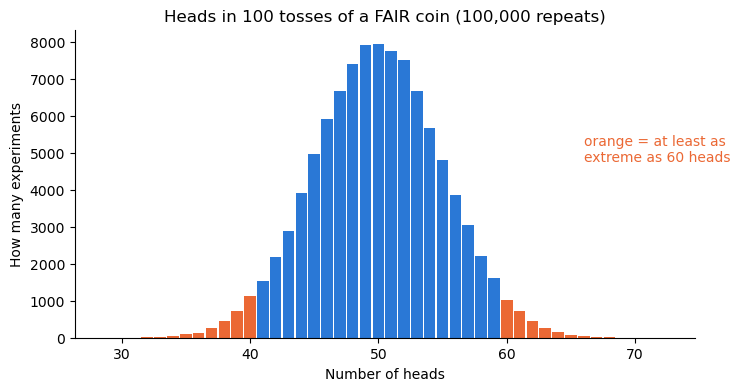

In [3]:
fig, ax = plt.subplots()
values, counts = np.unique(heads_per_experiment, return_counts=True)
colours = [ORANGE if (v >= 60 or v <= 40) else BLUE for v in values]
ax.bar(values, counts, color=colours, width=0.9)
ax.set_title("Heads in 100 tosses of a FAIR coin (100,000 repeats)")
ax.set_xlabel("Number of heads")
ax.set_ylabel("How many experiments")
ax.text(66, counts.max() * 0.6, "orange = at least as\nextreme as 60 heads", color=ORANGE)
plt.show()

The orange bars are the "at least as extreme" results. They make up about 5.7% of all experiments. So **p ≈ 0.057**.

**The same with a formula (normal approximation).** The number of heads in 100 fair tosses has mean $np = 50$ and standard deviation $\sqrt{np(1-p)} = \sqrt{25} = 5$.

$$z = \frac{60 - 50}{5} = 2$$

Area beyond |z| = 2 on both sides = 2 × (1 − 0.9772) = **0.0455**

The exact answer (binomial test) is in between the two. The normal approximation is a bit rough with only 100 tosses.

In [4]:
z = (60 - 50) / 5
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
p_value_normal = 2 * (1 - stats.norm.cdf(z))
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html
p_value_exact = stats.binomtest(60, n=100, p=0.5).pvalue

print(f"normal approximation: {p_value_normal:.4f}")
print(f"exact binomial test : {p_value_exact:.4f}")
print(f"simulation          : {p_value_simulated:.4f}")

normal approximation: 0.0455
exact binomial test : 0.0569
simulation          : 0.0571


### What the p-value is NOT

| Wrong reading | Why it's wrong |
|---|---|
| "p = 0.057 means a 5.7% chance the coin is fair" | The p-value assumes H₀ is true. It can't also be the probability that H₀ is true |
| "A small p-value means a big effect" | With huge samples, tiny unimportant effects get tiny p-values |
| "p > 0.05 proves there is no effect" | It only means we didn't find enough evidence. Maybe the sample was too small |

Read more: [The ASA statement on p-values (2016)](https://doi.org/10.1080/00031305.2016.1154108), a short official note on how p-values are misused

---
## 4. Significance level (α) and the decision

> **Theory.** Before looking at the data, we choose a threshold **α (alpha)**, the significance level. It is the risk we accept of calling a fair coin unfair.

**Decision rule:**

- p-value ≤ α → $\color{red}{\textbf{reject } H_0}$ (the result is "statistically significant")
- p-value > α → $\color{green}{\textbf{fail to reject } H_0}$

α = 0.05 is common, but it is a choice, not a law. In medicine people use 0.01 or smaller. In quick product experiments 0.10 is sometimes used. The domain decides.

**Coin result:** exact p = 0.057 > 0.05 → we $\color{green}{\textbf{fail to reject } H_0}$. 60 heads is a bit suspicious, but not strong enough evidence at α = 0.05.

### Rejection regions

Instead of comparing p with α, we can compare the test statistic with a **critical value**. For a two-tailed test with α = 0.05, we put 2.5% in each tail of the normal curve. The z values that cut off those tails are **±1.96**.

critical z for a two-tailed test at alpha = 0.05: 1.96


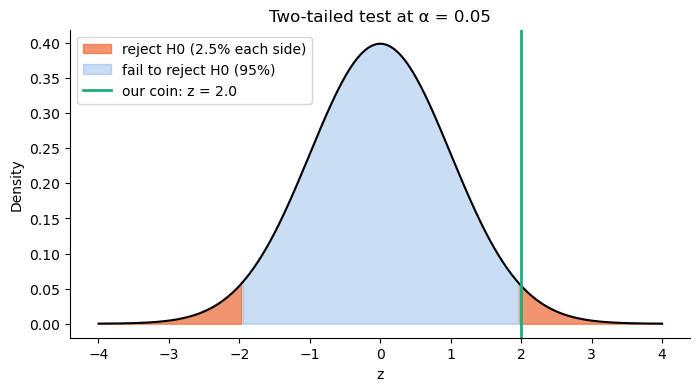

In [5]:
alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha / 2)
print("critical z for a two-tailed test at alpha = 0.05:", round(z_critical, 3))

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), color="black")
left, right = x <= -z_critical, x >= z_critical
ax.fill_between(x[left], stats.norm.pdf(x[left]), color=ORANGE, alpha=0.7, label="reject H0 (2.5% each side)")
ax.fill_between(x[right], stats.norm.pdf(x[right]), color=ORANGE, alpha=0.7)
middle = ~left & ~right
ax.fill_between(x[middle], stats.norm.pdf(x[middle]), color=BLUE, alpha=0.25, label="fail to reject H0 (95%)")
ax.axvline(2.0, color=GREEN, linewidth=2, label="our coin: z = 2.0")
ax.set_title("Two-tailed test at α = 0.05")
ax.set_xlabel("z")
ax.set_ylabel("Density")
ax.legend(loc="upper left")
plt.show()

With the normal approximation, our z = 2.0 lands just inside the orange area (2.0 > 1.96), so that method would say "reject". The exact test says p = 0.057, "don't reject". When a result sits this close to the line, the honest answer is: **borderline, collect more data**. Don't build a big decision on it.

---
## 5. One-tailed vs two-tailed tests

> **Theory.** It depends on the question.

**Example:** colleges in a region have an 85% placement rate. A new college says its placement rate is 88% (sample of 150 students).

| Question | H₁ | Test | Where is α? |
|---|---|---|---|
| Is the new college **different** from 85%? | p ≠ 0.85 | two-tailed | α/2 in each tail (±1.96) |
| Is the new college **better** than 85%? | p > 0.85 | one-tailed (right) | all of α in the right tail (+1.645) |
| Is the new college **worse** than 85%? | p < 0.85 | one-tailed (left) | all of α in the left tail (−1.645) |

In [6]:
print("two-tailed critical value :", round(stats.norm.ppf(0.975), 3))
print("one-tailed critical value :", round(stats.norm.ppf(0.95), 3))

two-tailed critical value : 1.96
one-tailed critical value : 1.645


A one-tailed test finds effects in its direction more easily (1.645 instead of 1.96), but it is blind to the other direction. Choose it **before** looking at the data and only if the other direction truly doesn't matter. Picking the tail after seeing the data is cheating.

---
## 6. Type I and type II errors

Every decision can be wrong in two ways.

| | H₀ is really true | H₀ is really false |
|---|---|---|
| **We reject H₀** | $\color{red}{\textbf{Type I error}}$ (false positive) | $\color{green}{\text{correct}}$ (this is **power**) |
| **We don't reject H₀** | $\color{green}{\text{correct}}$ | $\color{red}{\textbf{Type II error}}$ (false negative) |

Court version: type I = an innocent person is jailed. Type II = a guilty person walks free.

| Error | Probability | Controlled by |
|---|---|---|
| Type I | α | We choose it directly |
| Type II | β | Sample size, effect size, α |
| Power | 1 − β | Chance to detect a real effect |

### Simulation: when H₀ is true, we still reject about α of the time

We toss a truly fair coin 100 times, run the exact test, and repeat 2,000 times.

In [7]:
np.random.seed(1)
runs = 2000

false_alarms = 0
for _ in range(runs):
    heads = np.random.binomial(100, 0.5)
    if stats.binomtest(heads, 100, 0.5).pvalue <= 0.05:
        false_alarms += 1

print(f"Fair coin, rejected H0 in {false_alarms / runs:.1%} of the runs (type I error rate)")

Fair coin, rejected H0 in 3.3% of the runs (type I error rate)


Even with a perfectly fair coin, we "find" an unfair coin in a few percent of the experiments. This is the price of α. (The exact binomial test is a bit conservative, so the rate is slightly below 5%.)

### Simulation: when the coin is really unfair, how often do we catch it?

Now the coin truly gives heads 60% of the time. How often does the test notice, for different numbers of tosses?

In [8]:
np.random.seed(2)
results = []
for tosses in [20, 50, 100, 200, 400]:
    detected = 0
    for _ in range(1000):
        heads = np.random.binomial(tosses, 0.6)
        if stats.binomtest(heads, tosses, 0.5).pvalue <= 0.05:
            detected += 1
    results.append({"tosses": tosses, "power": detected / 1000})

power_table = pd.DataFrame(results)
power_table["type II error"] = 1 - power_table["power"]
power_table

,tosses,power,type II error
0,20,0.122,0.878
1,50,0.265,0.735
2,100,0.469,0.531
3,200,0.793,0.207
4,400,0.976,0.024


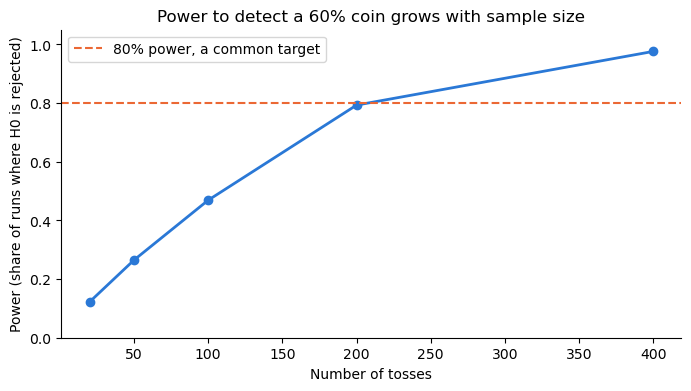

In [9]:
fig, ax = plt.subplots()
ax.plot(power_table["tosses"], power_table["power"], marker="o", color=BLUE, linewidth=2)
ax.axhline(0.8, color=ORANGE, linestyle="--", label="80% power, a common target")
ax.set_title("Power to detect a 60% coin grows with sample size")
ax.set_xlabel("Number of tosses")
ax.set_ylabel("Power (share of runs where H0 is rejected)")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

With 20 tosses we catch the unfair coin only about 1 time in 8. With 200 tosses we catch it about 8 times in 10. **Small samples miss real effects.** This is exactly why A/B tests need a sample size calculation before starting (we do this in the experimentation notebooks).

---
## 7. Confidence intervals

> **Theory.** A sample mean is a **point estimate**: one number that estimates the population mean. But it is never exactly right. A **confidence interval (CI)** adds a range around it:

$$\text{CI} = \text{point estimate} \pm \text{margin of error}$$

**Why do we need it?** "The average tip is 16.1%" sounds precise. "The average tip is between 15.3% and 16.9%" is honest about the uncertainty.

### 7a. When the population standard deviation σ is known: z interval

**Formula**

$$\bar{x} \pm z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

| Symbol | Meaning |
|---|---|
| $\bar{x}$ | sample mean |
| $z_{\alpha/2}$ | critical value, 1.96 for 95% |
| $\sigma / \sqrt{n}$ | **standard error**: how much the sample mean wobbles from sample to sample |

**Example.** In an entrance exam, the population sd is known to be 100. A sample of 25 students has a mean of 520. Build a 95% CI.

**By hand**

1. Standard error = 100 / √25 = 100 / 5 = 20
2. Margin of error = 1.96 × 20 = 39.2
3. CI = 520 ± 39.2 = **[480.8, 559.2]**

In [10]:
x_bar, sigma, n = 520, 100, 25

standard_error = sigma / np.sqrt(n)
z_crit = stats.norm.ppf(0.975)
margin = z_crit * standard_error

print(f"standard error = {standard_error}")
print(f"95% CI by hand  : [{x_bar - margin:.1f}, {x_bar + margin:.1f}]")
print(f"95% CI by scipy : {np.round(stats.norm.interval(0.95, loc=x_bar, scale=standard_error), 1)}")

standard error = 20.0
95% CI by hand  : [480.8, 559.2]
95% CI by scipy : [480.8 559.2]


### 7b. When σ is unknown: t interval

In real life we almost never know σ. We only have the sample standard deviation $s$. Using $s$ adds extra uncertainty, so we use the **t distribution** instead of the normal. It looks like the normal curve but with fatter tails, and it depends on the **degrees of freedom** df = n − 1. With big samples it becomes almost identical to the normal.

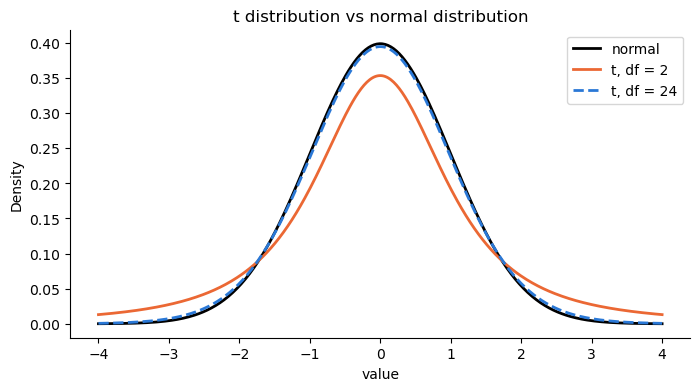

In [11]:
x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), color="black", linewidth=2, label="normal")
# docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html
ax.plot(x, stats.t.pdf(x, df=2), color=ORANGE, linewidth=2, label="t, df = 2")
ax.plot(x, stats.t.pdf(x, df=24), color=BLUE, linewidth=2, linestyle="--", label="t, df = 24")
ax.set_title("t distribution vs normal distribution")
ax.set_xlabel("value")
ax.set_ylabel("Density")
ax.legend()
plt.show()

With df = 2 the tails are much fatter. With df = 24 the t curve is already very close to the normal one.

**Formula**

$$\bar{x} \pm t_{\alpha/2,\ n-1} \cdot \frac{s}{\sqrt{n}}$$

**Example.** Same exam, 25 students, mean 520, but now we only know the sample sd s = 80.

**By hand**

1. df = 25 − 1 = 24 → t-table at 0.025 → **2.064**
2. Standard error = 80 / 5 = 16
3. Margin = 2.064 × 16 = 33.02
4. CI = 520 ± 33.02 = **[486.98, 553.02]**

In [12]:
x_bar, s, n = 520, 80, 25

t_crit = stats.t.ppf(0.975, df=n - 1)
margin = t_crit * s / np.sqrt(n)

print(f"t critical value = {t_crit:.3f}")
print(f"95% CI by hand  : [{x_bar - margin:.2f}, {x_bar + margin:.2f}]")
print(f"95% CI by scipy : {np.round(stats.t.interval(0.95, df=n - 1, loc=x_bar, scale=s / np.sqrt(n)), 2)}")

t critical value = 2.064
95% CI by hand  : [486.98, 553.02]
95% CI by scipy : [486.98 553.02]


### 7c. On real data: the average tip percentage

In [13]:
tip_pct = tips["tip_percent"]
n = len(tip_pct)
mean_tip = tip_pct.mean()
se = tip_pct.std() / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)

low, high = mean_tip - t_crit * se, mean_tip + t_crit * se
print(f"n = {n}, mean = {mean_tip:.2f}%, sd = {tip_pct.std():.2f}, standard error = {se:.3f}")
print(f"95% CI for the average tip percentage: [{low:.2f}%, {high:.2f}%]")

n = 244, mean = 16.08%, sd = 6.11, standard error = 0.391
95% CI for the average tip percentage: [15.31%, 16.85%]


In plain words: based on these 244 bills, the average tip at this restaurant is very likely between about 15.3% and 16.9% of the bill.

### Higher confidence = wider interval

In [14]:
for level in [0.80, 0.90, 0.95, 0.99]:
    t_crit = stats.t.ppf(1 - (1 - level) / 2, df=n - 1)
    print(f"{level:.0%} CI: [{mean_tip - t_crit * se:.2f}, {mean_tip + t_crit * se:.2f}]   width = {2 * t_crit * se:.2f}")

80% CI: [15.58, 16.58]   width = 1.00
90% CI: [15.43, 16.73]   width = 1.29
95% CI: [15.31, 16.85]   width = 1.54
99% CI: [15.07, 17.10]   width = 2.03


To be more confident that the interval catches the true value, we need a wider net. The only way to get a narrow **and** confident interval is more data (the standard error shrinks with √n).

---
## 8. What "95% confident" really means

This is one of the most misunderstood ideas in statistics.

$\color{red}{\textbf{Wrong:}}$ "there is a 95% probability that the true mean is inside this particular interval".

$\color{green}{\textbf{Right:}}$ "if we repeated the whole sampling process many times, **95% of the intervals we build** would contain the true mean".

The true mean is fixed. It's the interval that changes from sample to sample. Let's see it. We treat the 481 men in the Galton data as the population, so we know the true mean. Then we draw 100 samples of 30 men and build a 95% CI from each.

In [15]:
np.random.seed(5)
true_mean = men.mean()
population = men.to_numpy()

intervals = []
for i in range(100):
    sample = np.random.choice(population, size=30, replace=False)
    m = sample.mean()
    half_width = stats.t.ppf(0.975, df=29) * sample.std(ddof=1) / np.sqrt(30)
    intervals.append((m - half_width, m + half_width))

hits = sum(low <= true_mean <= high for low, high in intervals)
print(f"{hits} of 100 intervals contain the true mean ({true_mean:.2f} cm)")

93 of 100 intervals contain the true mean (175.85 cm)


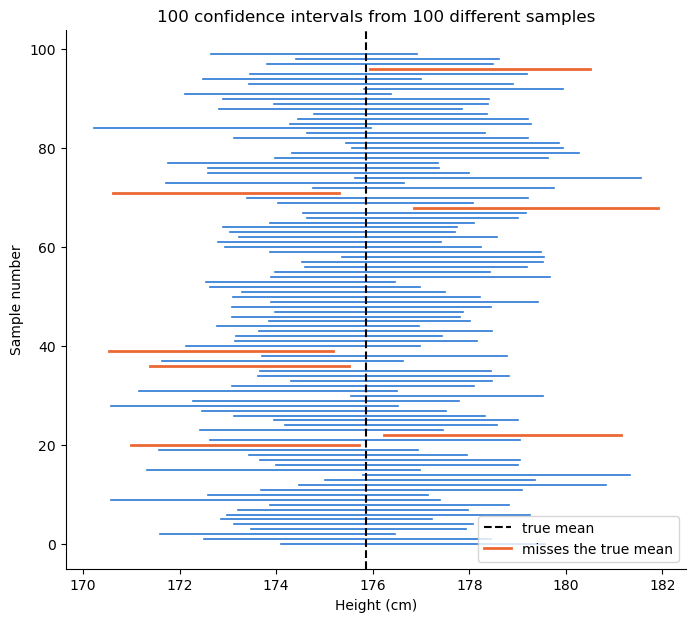

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))
for i, (low, high) in enumerate(intervals):
    contains = low <= true_mean <= high
    ax.plot([low, high], [i, i], color=BLUE if contains else ORANGE, linewidth=2 if not contains else 1.2)
ax.axvline(true_mean, color="black", linestyle="--", label="true mean")
ax.set_title("100 confidence intervals from 100 different samples")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Sample number")
ax.plot([], [], color=ORANGE, linewidth=2, label="misses the true mean")
ax.legend(loc="lower right")
plt.show()

Each line is one 95% interval. Most of them (blue) cross the true mean. A few (orange) miss it completely, even though nothing went "wrong" in the calculation. In this run 7 of the 100 missed. Over many repeats, the miss rate settles at about 5 in 100. That is what 95% confidence means.

Read more: [Seeing Theory: confidence intervals](https://seeing-theory.brown.edu/frequentist-inference/index.html) has an interactive version of this simulation

### Link between CIs and tests

A 95% CI and a two-tailed test at α = 0.05 always agree:

- if the H₀ value is **outside** the 95% CI → p < 0.05 → $\color{red}{\text{reject}}$
- if it is **inside** → p > 0.05 → $\color{green}{\text{don't reject}}$

For the tips: is the average tip 15%? 15 is just below our interval [15.3, 16.9], so we would reject "average tip = 15%" at α = 0.05. We will run this exact test in the next notebook.

---
## Summary

| Concept | Meaning |
|---|---|
| H₀ / H₁ | "Nothing going on" vs what we suspect |
| p-value | Chance of a result at least this extreme **if H₀ were true** |
| α | Threshold we pick in advance, also the type I error rate |
| p ≤ α | $\color{red}{\text{reject } H_0}$ ("statistically significant") |
| Critical values | ±1.96 (two-tailed, 5%), 1.645 (one-tailed, 5%) |
| Type I error | False positive, probability α |
| Type II error | False negative, probability β |
| Power | 1 − β, grows with sample size and effect size |
| Standard error | σ / √n, how much the sample mean wobbles |
| CI | Estimate ± critical value × standard error |
| z vs t interval | σ known → z. σ unknown → t with n − 1 df |

## What's next

In **06 · Z-Test, T-Test and Chi-Square Test** we run complete tests step by step: one-sample z-test, one-sample t-test, z-test for a proportion, and the chi-square goodness-of-fit test.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapter 5 (foundations for inference)
- Wasserstein & Lazar (2016), [The ASA Statement on p-Values: Context, Process, and Purpose](https://doi.org/10.1080/00031305.2016.1154108)
- [Type I and type II errors, Wikipedia](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors) · [Statistical power, Wikipedia](https://en.wikipedia.org/wiki/Power_(statistics))
- [scipy `binomtest`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html) · [scipy `t`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html)